In [1]:
import os
os.chdir('..')

In [3]:
%load_ext autoreload
%autoreload 2
from dataset.chatter_image import ChatterImage
from model.cnn import CNN


from trainer.classifier import ClassifierTrainer
import torch
import numpy as np
import os
from torchvision import transforms
from utils.plot_utils import plot_confusion_matrix

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
SEED = 47
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [7]:
hyperparams = dict(lr=0.001, train_batch_size=8, test_batch_size=8, epoch=2, train_shuffle=True, test_shuffle=False)
params = dict(log_interval=10, result_path='../results/chatter_cnn_images')

In [8]:
dataset = ChatterImage(root='D:/YandexDisk/machining/chatter_cnn_images/Chatter_cnn',
                           transform=transforms.Compose([transforms.ToTensor()]),
                           )

Reading images...:  13%|███████▉                                                    | 200/1519 [00:08<00:54, 24.03it/s]


====== Trainset Info ======

                data.shape:(150, 200, 5120)
                targets.shape:(150,)
                targets.mean: 0.13333334028720856
        
====== Testset Info ======

                data.shape:(50, 200, 5120)
                targets.shape:(50,)
                targets.mean: 1.0
        


In [9]:
model = CNN(in_channels=1, out_channels=1)

In [10]:
trainer = ClassifierTrainer(model=model, dataset=dataset, hyperparams=hyperparams, params=params)

In [11]:
trainer.fit()

Test	Epoch: 0 [0/50 (0%)]	Batch Loss: 0.796460	Batch Acc: 0.0
Train	Epoch: 1 [0/150 (0%)]	Batch Loss: 0.611742	Batch Acc: 88.0
Train	Epoch: 1 [80/150 (53%)]	Batch Loss: 0.406937	Batch Acc: 88.0
Test	Epoch: 1 [0/50 (0%)]	Batch Loss: 1.788888	Batch Acc: 0.0
Train	Epoch: 2 [0/150 (0%)]	Batch Loss: 0.520809	Batch Acc: 75.0
Train	Epoch: 2 [80/150 (53%)]	Batch Loss: 0.175846	Batch Acc: 100.0
Test	Epoch: 2 [0/50 (0%)]	Batch Loss: 0.559083	Batch Acc: 75.0


In [12]:
trainer.history.save(fpath=params['result_path'])
trainer.history.plot(fpath=params['result_path'])

In [13]:
train_prediction = trainer.predict(dataloader=trainer.train_loader)

C:\Users\ugurg\Documents\GitHub\ai-framework\src\trainer\classifier.py:124: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  output = torch.nn.functional.softmax(output)


In [14]:
test_prediction = trainer.predict()

In [15]:
train_true = trainer.dataset.trainset.targets
test_true = trainer.dataset.testset.targets

<Figure size 432x288 with 0 Axes>

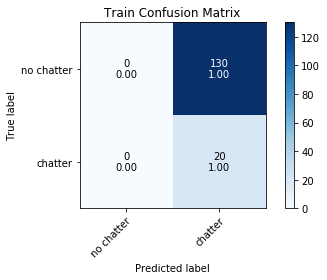

In [22]:
plot_confusion_matrix(y_true=train_true,
                      y_pred=train_prediction, 
                      classes=['no chatter', 'chatter'],
                     title='Train Confusion Matrix',
                     save_path=params['result_path']+'/train_cm')

<Figure size 432x288 with 0 Axes>

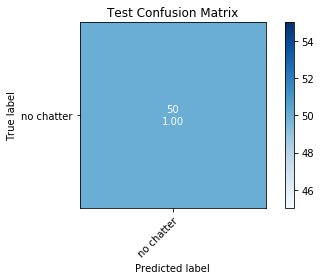

In [23]:
plot_confusion_matrix(y_true=test_true,
                      y_pred=test_prediction, 
                      classes=['no chatter', 'chatter'],
                     title='Test Confusion Matrix',
                     save_path=params['result_path']+'/test_cm')

In [18]:
trainer.model

CNN(
  (feature_extractor): Sequential(
    (0): Conv2d(1, 20, kernel_size=(3, 6), stride=(1, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=(3, 6), stride=(3, 6), padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(20, 50, kernel_size=(3, 6), stride=(1, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=(3, 6), stride=(3, 6), padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(50, 10, kernel_size=(3, 6), stride=(1, 2))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=(3, 6), stride=(3, 6), padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=120, out_features=100, bias=True)
    (1): Linear(in_features=100, out_features=1, bias=True)
  )
)